<a href="https://colab.research.google.com/github/manowar077/Machine-Learning/blob/main/How_Data_Feed_To_ML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**What is Batch Learning?**

Batch learning, also termed offline learning, is that type of learning where the model undergoes a training process from the entire batch of data. Normally, it involves feeding of what is referred to as batch data, which includes inputting all available data at once into the learning algorithm; a process which results in the creation of a model that can be used to make the prediction. Once trained, the model is not updated by default; the only way to rebuild a given model is restructuring it with new data.

During batch learning, data is gathered over time. The machine learning model is then periodically trained using this accumulated data in batches. Because the model is unable to learn progressively from a stream of real-time data, it is the exact reverse of online learning. In batch learning, the machine learning algorithm does not modify its parameters until batches of fresh data have been consumed.

Large batches of accumulated data are used to train models, which requires more time and resources like CPU, memory, and disc input/output. Additionally, it requires more time to deploy models into production because this can only be done periodically depending on how well the model performs after being trained with fresh data.

READ ARTICLE :https://medium.com/data-scientists-diary/online-vs-batch-learning-in-machine-learning-385d21511ec3

Another Detailed Article :https://medium.com/data-scientists-diary/online-vs-batch-learning-in-machine-learning-385d21511ec3

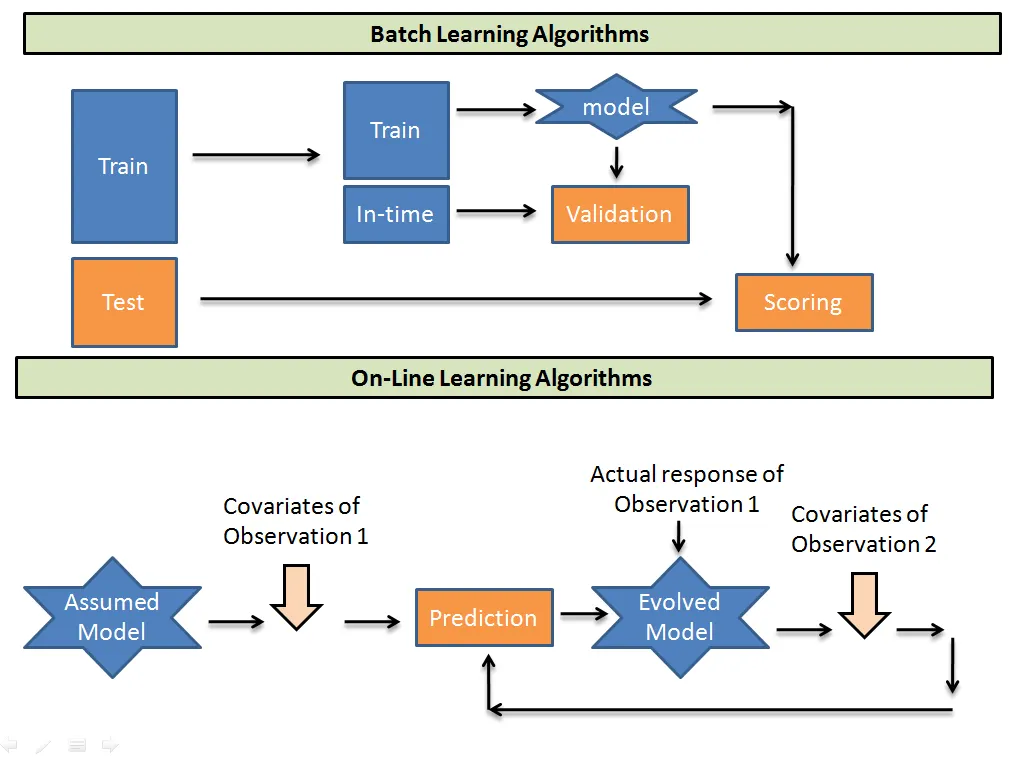

In [2]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Generate some synthetic data
X = np.random.rand(1000, 1) * 10
y = 2.5 * X + np.random.randn(1000, 1) * 2

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

Mean Squared Error: 4.27284533345758


## Detailed Summary

This code demonstrates **Batch Learning** using **Ordinary Least Squares (OLS) Linear Regression**. Unlike the previous `SGDRegressor` example, here the model is trained **once using the complete training dataset**.

### 1. Import the libraries

```python
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
```

These libraries provide the necessary functionality:

*   **NumPy (`np`)** → generates and manipulates numerical data.
*   **`LinearRegression`** → implements linear regression.
*   **`train_test_split`** → divides the dataset into training and testing subsets.
*   **`mean_squared_error`** → evaluates prediction performance.

---

### 2. Generate synthetic data

```python
X = np.random.rand(1000, 1) * 10
y = 2.5 * X + np.random.randn(1000, 1) * 2
```

The program generates **1,000 observations**.

The input variable (X) contains random values between 0 and 10.

The target variable (y) is generated according to:

$$y = 2.5X + \epsilon$$

where (\epsilon) represents normally distributed random noise.

Therefore, the underlying relationship between (X) and (y) is approximately:

$$\boxed{y = 2.5X}$$

The noise makes the dataset more realistic because real-world observations rarely follow a perfectly deterministic relationship.

---

### 3. Split the dataset

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
```

The dataset is divided into two subsets:

*   **80% → Training data**
*   **20% → Testing data**

Since there are 1,000 observations:

$$1000 \times 0.8 = 800$$

So approximately:

```text
800 observations → Training
200 observations → Testing
```

The training set is used to **estimate the model parameters**, while the test set is reserved for **evaluating generalization performance**.

`random_state=42` ensures that the same random split can be reproduced when the program is executed again.

---

### 4. Create the regression model

```python
model = LinearRegression()
```

This creates an instance of the **Linear Regression** model.

The model attempts to learn the relationship:

$$\hat{y} = wX + b$$

where:

*   (w) = regression coefficient/slope
*   (b) = intercept
*   ($\hat{y}$) = predicted value

Because the synthetic data was generated using a coefficient of approximately **2.5**, we expect the learned coefficient to be close to 2.5.

---

### 5. Train the model

```python
model.fit(X_train, y_train)
```

This is the most important step for **Batch Learning**.

The model receives the **entire training dataset at once**:

```text
800 training observations
        ↓
   LinearRegression
        ↓
Estimate parameters
        ↓
   Final model
```

Linear Regression typically estimates the parameters by minimizing the **sum of squared residuals**:

$$\min_{w,b}
\sum_{i=1}^{n}(y_i-(wX_i+b))^2$$

Unlike the previous online-learning example, there is no repeated `partial_fit()` process here.

The model is trained on the available training dataset in a single fitting operation.

---

### 6. Generate predictions

```python
y_pred = model.predict(X_test)
```

After training, the model receives the **unseen test data** and generates predictions.

For example:

```text
X_test → Trained model → y_pred
```

These predicted values are then compared with the actual `y_test` values.

---

### 7. Calculate Mean Squared Error

```python
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
```

The model is evaluated using **Mean Squared Error (MSE)**:

$$MSE = \frac{1}{n}
\sum_{i=1}^{n}(y_i-\hat{y}_i)^2$$

MSE measures how far the model's predictions are from the actual observations.

*   **Lower MSE** → better predictive performance.
*   **Higher MSE** → larger prediction errors.

Because the dataset contains random noise, the MSE will not normally be zero.

---

## Overall Workflow

```text
Generate 1,000 observations
          ↓
Create synthetic relationship
          ↓
Split data
          ↓
800 Training samples + 200 Testing samples
          ↓
Train LinearRegression
using all training data
          ↓
Generate predictions
on test data
          ↓
Calculate Mean Squared Error
          ↓
Evaluate generalization
```

## Batch Learning vs. Your Previous Online Learning Code

| Feature                | Batch Learning               | Online/Incremental Learning |
| :--------------------- | :--------------------------- | :-------------------------- |
| Model                  | `LinearRegression`           | `SGDRegressor`              |
| Training method        | `fit()`                      | `partial_fit()`             |
| Data processing        | Entire training set          | Small batches/increments    |
| Parameter updates      | During the fitting operation | Repeatedly as data arrives  |
| Suitable for           | Relatively static datasets   | Streaming/changing datasets |
| Memory requirement     | Can be higher                | Generally more manageable   |
| Adaptation to new data | Requires retraining          | Can update incrementally    |

### Key Concept

The fundamental difference is **how the model receives data**.

**Batch Learning:**

$$\text{Complete training dataset}
\rightarrow
\text{Model training}
\rightarrow
\text{Final model}$$

**Online Learning:**

$$\text{New data}
\rightarrow
\text{Parameter update}
\rightarrow
\text{New data}
\rightarrow
\text{Parameter update}
\rightarrow \cdots$$

So, this code is a straightforward example of **batch learning**, where `LinearRegression.fit()` estimates the regression parameters using the complete training dataset before the model is evaluated on previously unseen test data.

In [ ]:
import numpy as np
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

# Generate some synthetic data
X = np.random.rand(1000, 1) * 10
y = 2.5 * X + np.random.randn(1000, 1) * 2

# Create the online learning model
model = SGDRegressor()

# Simulate online learning by feeding data in small batches
batch_size = 10
n_batches = len(X) // batch_size

for i in range(n_batches):
    start = i * batch_size
    end = start + batch_size
    model.partial_fit(X[start:end], y[start:end].ravel())

# Make predictions and evaluate the model on the entire dataset
y_pred = model.predict(X)
print("Mean Squared Error:", mean_squared_error(y, y_pred))

### Detailed Summary

The given Python program demonstrates **incremental (online) learning** using **Stochastic Gradient Descent (SGD)** for a regression problem.

#### 1. Libraries

The code imports:

*   **NumPy (`numpy`)** — for numerical operations and generating synthetic data.
*   **`SGDRegressor`** — a scikit-learn model that performs linear regression using stochastic gradient descent.
*   **`mean_squared_error`** — used to measure the difference between actual and predicted values.

#### 2. Dataset Generation

The program creates **1,000 synthetic observations**.

The input variable (X) contains random values between 0 and 10. The target variable (y) is generated according to:

$$y = 2.5X + \epsilon$$

where (\epsilon) is normally distributed random noise.

Therefore, the underlying relationship is approximately **linear**, with a theoretical slope of **2.5**.

#### 3. Model Initialization

```python
model = SGDRegressor()
```

An `SGDRegressor` is created to learn the relationship between (X) and (y).

The model attempts to estimate:

$$\hat{y} = wX + b$$

where:

*   ($w$) = learned coefficient/slope
*   ($b$) = learned intercept
*   ($\hat{y}$) = predicted target

The parameters are optimized using **gradient descent**.

#### 4. Incremental Training

The dataset is divided into batches of **10 observations**:

$$1000 / 10 = 100 \text{ batches}$$

The loop processes these batches sequentially.

```python
model.partial_fit(X[start:end], y[start:end].ravel())
```

The important function here is **`partial_fit()`**.

Instead of retraining the model from scratch every time new data arrives, `partial_fit()` updates the existing model parameters using the newly provided observations.

Conceptually:

```text
Batch 1 → Update parameters
Batch 2 → Update parameters
Batch 3 → Update parameters
       ↓
Batch 100 → Final parameter update
```

This simulates a real-world **streaming-data environment**.

#### 5. Why SGD Is Used

**Stochastic Gradient Descent** updates model parameters based on individual observations or small groups of observations.

The basic idea is:

$$\theta_{t+1} = \theta_t-\eta\nabla L(\theta_t)$$

where:

*   ($\theta$) = model parameters
*   ($\eta$) = learning rate
*   ($L$) = loss function
*   ($\nabla L$) = gradient of the loss

The model repeatedly adjusts its parameters to reduce prediction error.

#### 6. Prediction

After processing all batches:

```python
y_pred = model.predict(X)
```

The trained model predicts ($y$) for all 1,000 input observations.

These predictions are then compared with the actual target values.

#### 7. Model Evaluation

The program uses **Mean Squared Error (MSE)**:

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i-\hat{y}_i)^2$$

MSE measures the average squared prediction error.

*   **Lower MSE** → predictions are closer to actual values.
*   **Higher MSE** → predictions have larger errors.

Because the synthetic dataset intentionally contains random noise, the model cannot achieve zero error.

---

### Overall Workflow

```text
Generate 1,000 observations
          ↓
Create synthetic linear relationship
          ↓
Initialize SGDRegressor
          ↓
Split data into batches of 10
          ↓
Process batch 1 → Update model
          ↓
Process batch 2 → Update model
          ↓
        ...
          ↓
Process batch 100 → Update model
          ↓
Generate predictions
          ↓
Calculate Mean Squared Error
          ↓
Evaluate model performance
```

### Key Concept

The main purpose of this example is to demonstrate that **machine-learning models do not always need to be trained on the complete dataset simultaneously**.

With incremental learning, the model can continuously incorporate new observations:

> **New data → parameter update → improved/adapted model**

This is particularly useful when dealing with **large-scale datasets, streaming data, real-time systems, and environments where the underlying data distribution changes over time**.

**In short:** the code simulates online learning by feeding an `SGDRegressor` small batches of data sequentially and using `partial_fit()` to update the model incrementally.

Advantages and Limitations
Batch Learning

**Advantages:**

1.High Accuracy:
 May yield highly accurate models because of analysis that covers the total information on the data set.
Stability: Once trained, models do not change and, hence are not impacted the same way until the next time they are trained again.
Simplicity: It needs to be noted that the decision-making types defined under this approach are easier to implement and manage and do not require constant updates.

**Limitations:**

1.Resource Intensive: Most complex and computationally intensive demanding data storage and memory in large data sets.

2.Slow Adaptation: Inadequate in modeling new data, and for the update, it requires the model to be retrained from the ground up.

3.Latency: Rather long intervals between changes to the model, which means it is not suitable for use in delivering real-time results.

**Online Learning**

**Advantages:**

**Efficiency: **

Smaller resource requirements on at least one phase of the iterative process, useful for big data or streaming data.

Adaptability: Capable of being rapidly updated with new data, which makes it appropriate for fast-changing circumstances.

Real-Time Performance: In some cases it can be done with a relatively short delay, thus being very reactive to changes.
Limitations:

Complexity: While it is easier to create specific goals, objectives, and targets, they are more difficult to implement and manage because new ones have to be added from time to time, especially when the current state of business changes.

2. Accuracy Variability: Accuracy is possible and due to the non-stationariness of the data, performance might be overfitting to noisy data if not addressed.

3. Data Dependency: Lacks robust features for model maintenance, the model’s performance can be drastically affected if fresh data is not continuously supplied.

**Conclusion**
Batch learning and online learning are two very different methods with their own strengths to be utilized in the field of machine learning. Batch learning is useful where data is fixed and where high accuracy and the amount of model fluctuations are important. With reference to the last point, it could be said that online learning fits well into the highly dynamic environments where data is constantly being produced and therefore, a rather timely action is required. The identification of these two approaches has the following considerations: the nature of the data, the computational facilities available, and the need for model recalibration. It is only when one has gained an understanding of the differences and the use of both batch and online learning that the practitioner can effectively distinguish between the two and can proceed to apply the strengths of each in the given machine learning project.

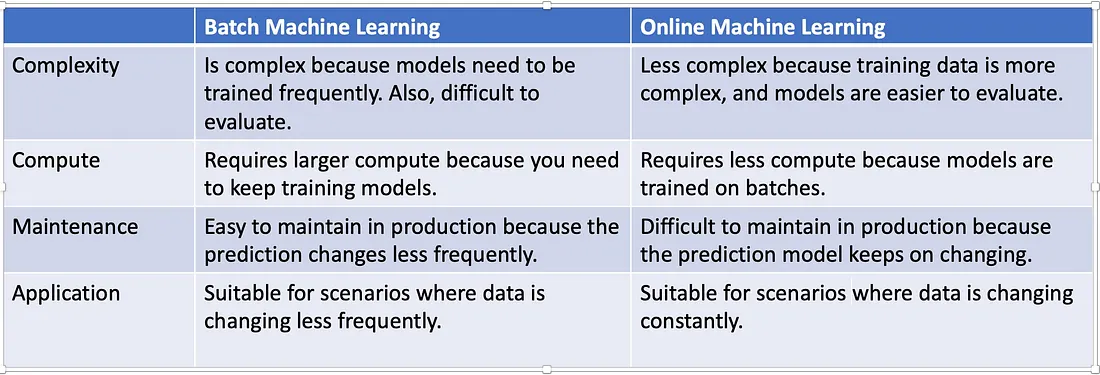